# Trabajo Práctico Integrador

## Port Log - Sprint 1

## Integrantes del grupo:

- Hector Oviedo
- Sofia Antonia Gamallo
- Alexander Seling
- Nicolas Hugo Diaz
- Ivan Agustin Sandiyu

## Repositorio GITHUB

Especificar en la siguiente línea cual es la url para acceder al repositorio del grupo.



>https://github.com/HectorOviedoM/Port_Log-Grupo_16.git







## Consideraciones Generales e Importantes

- Desarrollo base: Los puntos solicitados son la base del trabajo práctico. Es posible la ampliación sin restricciones del mismo.
- Para el traceo se deben agregar 1 [secrets](https://drlee.io/how-to-use-secrets-in-google-colab-for-api-key-protection-a-guide-for-openai-huggingface-and-c1ec9e1277e0) para la utilización de github.
  - GITHUB_TOKEN
- Organización del Notebook:
  - Agregar antes del ejercicio 01 una celda donde se importan todas librerías necesarias.
  - Utilizar un título para cada celda y escribir cada funcionalidad en una celda con título.
- La defensa es individual.
- Los grupos deben mantenerse a lo largo del trabajo integrador.
- La opción `DESACTIVAR_GIT_PUSH` solo será utilizada por los profesores.

## Versionado y Trabajo en Equipo


- Control de Versiones: Utilizar herramientas de versionado
- Colaboradores: Brindar acceso al repositorio a las siguientes cuentas:
  - lcd-had141@ugr.edu.ar
  - fpasinato@ugr.edu.ar
- La descripción del commit debe ser con el siguiente formato `"Día X: \<comentario del commit\>"`
- Changelog: Cada ejercicio/punto del trabajo práctico es considerado como un día distinto de trabajo. Debe quedar constancia en un archivo CHANGELOG.md de los cambios generados cada día. El changelog debe escribirse de tal forma que lo primero que se observe es el último cambio realizado, de esta forma apenas se abre el archivo se pueden leer los últimos cambios realizados. La forma de escritura debe ser un encabezado entre corchetes [Ejercicio X] y luego debajo los cambios realizado como bullets.
- El archivo README.md debe contener el sprint en el que nos encontramos y debe contener:
  - El objetivo.
  - La introducción y el contexto del sprint de trabajo.

## Criterios de evaluación

- Funcionalidad: el código debe ejecutar sin errores al dar "Ejecutar todo" (Ctrl+F9). Validar con Runtime -> Restart session and run all antes de entregar.
- Claridad: código organizado, nombres descriptivos, comentarios solo donde corresponde (funciones, clases, métodos). No se admite `git add .`.
- Estilo: [type hints](https://docs.python.org/3/library/typing.html), [pep8](https://peps.python.org/pep-0008/).

- Herramientas: librerías vistas en la cursada. Sin gdrive ni herramientas alternativas.

## Condiciones de Entrega
- Archivo `.ipynb`, ejecutado y con datos precargados, sobre copia de la plantilla original manteniendo la nomenclatura del nombre.
- Canal: aula virtual. Correo a lcd-had141@ugr.edu.ar solo si el plazo finalizó. No se aceptan enlaces.
- Los trabajos que no cumplan con los requisitos no serán tomados en cuenta como nota final. Solo serán corregidos y evaluados con nota para la devolución correspondiente. Se considera incumplimiento a:
  - Entregas fuera de término.
  - Trabajos que no se entreguen sobre la plantilla de trabajo estipulada.
  - Trabajos que no se ejecuten completos (que contengan errores intermedios al dar "Ejecutar todo").

---

# Objetivo

Aplicar conocimientos de tratamiento de imágenes y programación limpia sobre el contexto del sistema portuario.

## Introducción y Contexto del problema


### Sprint 2 — Desarrollar

Los radares ubicados en los accesos a los muelles capturan evidencia fotográfica de las infracciones de velocidad. Las cámaras asociadas toman fotografías de la zona de proa donde está pintada la matrícula del buque. En algunos casos el sistema recorta automáticamente la zona de matrícula (`plates`); en otros, entrega la imagen completa (`completes`).

El sistema presenta las siguientes limitaciones:
- No todas las infracciones tienen imagen asociada.
- No todas las imágenes corresponden a una infracción real (falsos positivos del radar).
- Puede haber errores de detección óptica: imágenes borrosas, nocturnas o tomadas a gran distancia.

El objetivo es: **¿qué infracciones tienen evidencia visual válida?**

Datasets necesarios:
- Dataset procesado en Sprint 1.
- [Dataset de imágenes](https://github.com/HAD141/datasets/raw/refs/heads/main/TrabajosPracticos/port_log/port_log_images.zip): `https://github.com/HAD141/datasets/raw/refs/heads/main/TrabajosPracticos/port_log/port_log_images.zip`

---

# Configuración del equipo de trabajo





In [1]:
#@title Importaciones iniciales

import json
import os
import random
import shutil
import subprocess
import urllib.request
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import userdata

In [2]:
#@title Clase para trabajar con git

@dataclass(frozen=True)
class GitRepository:
    """
    Representa un repositorio Git y encapsula las operaciones necesarias
    para trabajar con él desde Google Colab.

    Las credenciales de cada integrante se obtienen de los Secrets
    de Colab, permitiendo que los commits queden asociados a su
    identidad individual.
    """
    owner: str
    repository: str
    path: Path
    usertoken: str | None

    @property
    def path_notebook(self: "GitRepository") -> Path:
        return self.path / "02_Port_Log_Grupo_16.ipynb"

    @property
    def path_readme(self: "GitRepository") -> Path:
        return self.path / "README.md"

    @property
    def path_changelog(self: "GitRepository") -> Path:
        return self.path / "CHANGELOG.md"

    @staticmethod
    def from_colab(repository: str, owner: str, path: Path) -> "GitRepository":
        """
        Crea un repositorio utilizando las credenciales almacenadas
        en los Secrets de Google Colab.
        """
        try:
            usertoken = userdata.get("GITHUB_TOKEN").strip()
        except userdata.SecretNotFoundError:
            usertoken = None


        return GitRepository(
            owner=owner,
            repository=repository,
            path=path,
            usertoken=usertoken,
        )

    @property
    def public_remote_url(self: "GitRepository") -> str:
        return f"https://github.com/{self.owner}/{self.repository}.git"

    def authenticated_remote_url(self: "GitRepository", token: str) -> str:
        return (
            f"https://x-access-token:{token}"
            f"@github.com/{self.owner}/{self.repository}.git"
        )


    def _run(self: "GitRepository", *args: str) -> subprocess.CompletedProcess:
        """Ejecuta un comando Git en el directorio de trabajo del repositorio."""
        try:
            return subprocess.run(
                ["git", *args],
                cwd=self.path,
                check=True,
                text=True,
                capture_output=True,
            )
        except subprocess.CalledProcessError as error:
            print(error.stderr.strip())
            raise

    def clone(self: "GitRepository") -> None:
        print(f"GIT: Clonando {self.public_remote_url}")
        subprocess.run(
            ["git", "clone", self.public_remote_url, str(self.path)],
            check=True,
            text=True,
        )

    def add(self, paths: list[str]) -> None:
        """Agrega archivos o directorios al área de staging."""
        print(f"GIT: ADDING {paths}")
        self._run("add", *paths)


    def fetch(self: "GitRepository") -> None:
        print(f"GIT: fetching origin")
        self._run("fetch", "origin")

    def checkout(self: "GitRepository", branch: str) -> None:
        print(f"GIT: checkingout to {branch}")
        self._run("checkout", branch)

    def has_rama(self: "GitRepository", branch: str) -> bool:
        """Indica si existe una rama en el repositorio remoto origin."""
        result = self._run(
            "branch",
            "--remotes",
            "--list",
            f"origin/{branch}",
        )

        exists = bool(result.stdout.strip())

        print(f"GIT: origin/{branch} exists: {exists}")

        return exists

    def create_branch(self: "GitRepository", branch: str) -> None:
        print(f"GIT: Creando branch {branch}")
        self._run("checkout", "-b", branch)

    def pull(self: "GitRepository", branch: str) -> None:
        print(f"GIT: Pulling branch {branch}")
        self._run("pull", "origin", branch)

    def reset_to_remote(self, branch: str) -> None:
        """Descarta cambios locales y sincroniza la rama con su versión remota."""
        print(f"GIT: Hard resetting to origin/{branch}")
        self._run("reset", "--hard", f"origin/{branch}")
        self._run("clean", "-fd")

    def status(self: "GitRepository") -> str:
        result = self._run("status")
        return result.stdout

    def configure_identity(self: "GitRepository", username: str, email: str) -> None:
        """Configura la identidad Git si difiere de la actual."""
        try:
            current_username = self._run("config", "user.name").stdout.strip()
            current_email = self._run("config", "user.email").stdout.strip()
        except subprocess.CalledProcessError:
            current_username = ""
            current_email = ""

        if current_username == username and current_email == email:
            print(f"Git: identidad ya configurada como {username} <{email}>.")
            return

        self._run("config", "user.name", username)
        self._run("config", "user.email", email)

        print(f"Git: identidad cambiada a {username} <{email}>.")

    def commit_as_user(
        self: "GitRepository",
        to_add: list[str],
        message: str,
        username: str,
        useremail: str,
    ) -> bool:
        """
        Configura la identidad indicada y crea el commit si hay cambios staged.
        """

        self.configure_identity(username, useremail)

        if to_add:
            self.add(to_add)

        result = subprocess.run(
            ["git", "diff", "--cached", "--quiet"],
            cwd=self.path,
        )

        if result.returncode == 0:
            print("GIT: no hay cambios para commitear.")
            return False

        self._run("commit", "-m", message)
        print(f"GIT: commit creado: {message}")
        return True

    def push(self: "GitRepository", branch: str) -> bool:
        """Sube la rama indicada usando el token, si está disponible."""

        if self.usertoken is None:
            print("Git: no hay token configurado; push omitido.")
            return False

        try:
            self._run(
                "push",
                "-u",
                self.authenticated_remote_url(self.usertoken),
                branch,
            )
        except subprocess.CalledProcessError:
            return False

        print(f"Git: rama '{branch}' subida a origin.")
        return True

In [3]:
#@title Clase para trabajar CHANGELOG.md

@dataclass(frozen=True)
class ChangelogEntry:
	day: int
	changes: tuple[str, ...]

	@property
	def header(self: "ChangelogEntry") -> str:
		return f"### Ejercicio {self.day:02d} — Día {self.day}"

	def to_markdown(self: "ChangelogEntry") -> str:
		changes = "\n".join(f"- {change}" for change in self.changes)
		return f"{self.header}\n{changes}"

@dataclass
class ChangelogWriter:
	path: Path
	sprint: int
	HEADER = "# Changelog\n"

	def print_head(self: "ChangelogWriter", lines: int = 10) -> None:
		"""Imprime las primeras líneas del CHANGELOG."""
		content = self.path.read_text(encoding="utf-8")

		if not content.startswith(self.HEADER):
			raise ValueError("El CHANGELOG.md no tiene el formato esperado.")

		print("\n".join(content.splitlines()[:lines]))

	@property
	def sprint_header(self: "ChangelogWriter") -> str:
		return f"## Sprint {self.sprint}"


	def try_add_and_update(
		self: "ChangelogWriter",
		entry: ChangelogEntry,
	) -> bool:
		"""Agrega una entrada al comienzo del sprint actual."""

		content = self.path.read_text(encoding="utf-8")

		if not content.startswith(self.HEADER):
			print("El CHANGELOG.md no tiene el formato esperado.")
			return False

		if entry.header in content:
			print(f"CHANGELOG: '{entry.header}' ya estaba registrado.")
			return False

		if self.sprint_header not in content:
			# El sprint no existe: lo crea después del encabezado principal.
			sprint_block = (
				f"{self.sprint_header}\n\n"
				f"{entry.to_markdown()}"
			)

			content = content.replace(
				self.HEADER,
				self.HEADER + "\n" + sprint_block + "\n",
				1,
			)

			self.path.write_text(content, encoding="utf-8")

			print(
				f"CHANGELOG: '{self.sprint_header}' creado "
				f"y '{entry.header}' agregado."
			)
			return True

		block = entry.to_markdown()
		marker = self.HEADER + "\n" + self.sprint_header

		content = content.replace(
			marker,
			marker + "\n\n" + block,
			1,
		)

		self.path.write_text(content, encoding="utf-8")

		print(f"CHANGELOG: '{entry.header}' agregado.")
		return True

In [4]:
#@title Procedimiento para ejecutar todo en una sola expresion

def tracear_ejercicio(
    repo: "GitRepository",
    log: "ChangelogWriter",
    entry: ChangelogEntry,
    commit_files: list[str],
    commit_message: str,
    commit_username: str,
    commit_useremail: str,
) -> None:
    if not log.try_add_and_update(entry):
        print("Ejercicio ya traceado en changelog")
        return

    if repo.commit_as_user(
        to_add=commit_files,
        message=commit_message,
        username=commit_username,
        useremail=commit_useremail,
    ):
        repo.push("Sprint_2")
    else:
        print("No hace falta hacer commitear")



In [5]:
#@title Globales iniciales

repo = GitRepository.from_colab(
    repository="Port_Log-Grupo_16",
    owner="HectorOviedoM",
    path=(
        Path.cwd() / "Port_Log-Grupo_16"
        if Path.cwd().name == "content"
        else Path.cwd()
        if Path.cwd().name == "Port_Log-Grupo_16"
        else Path.cwd() / "content/Port_Log-Grupo_16"
    ).resolve()
)
log = ChangelogWriter(
    path=repo.path_changelog,
    sprint=2,
)


# Configuraciones de la cátedra

In [6]:
#@title Catedra. Agregamos variables de entorno y secrets

HOOKS="/tmp/.git-templates/hooks"

try:
    DESACTIVAR_GIT_PUSH = bool(userdata.get('DESACTIVAR_GIT_PUSH'))
except userdata.SecretNotFoundError:
    DESACTIVAR_GIT_PUSH = False
os.environ['DESACTIVAR_GIT_PUSH'] = str(DESACTIVAR_GIT_PUSH)
os.environ['HOOKS'] = HOOKS

In [7]:
#@title Catedra. Creación del hook para que durante la corrección no se realicen modificaciones al repositorio
%%bash
mkdir -p $HOOKS
cat << EOF > $HOOKS/pre-push
#!/bin/sh
if [ "$DESACTIVAR_GIT_PUSH" = "'True'" ] || [ "$DESACTIVAR_GIT_PUSH" = "True" ]; then
    echo "[GIT HOOK - WARNING] Pushes are disabled for this repository."
    exit 1
fi
EOF

chmod +x $HOOKS/pre-push

# Ejercicio 01

> Puntos: 1

Clonar el repositorio del Sprint 1 y crear la rama `Sprint_2` partiendo de `Sprint_1`.

Descargar el dataset de imágenes, descomprimirlo y almacenarlo en `port_log/data/raw/imgs`.

Verificar que los siguientes archivos del Sprint 1 sean accesibles antes de continuar:
- `port_log/data/raw/port_movements.csv`
- `port_log/data/interim/port_movements.csv`. Este dataset se utilizará durante el desarrollo del notebook.
- `port_log/reports/summary_sprint1.csv`

Mostrar la cantidad de registros de cada uno.

In [8]:
#@title E01. Clonar el repo y crear la rama Sprint_2
#Trae el repo del Sprint 1 y abre (o crea) la rama Sprint_2




if not repo.path.exists():
    repo.clone()
repo.fetch()

if repo.has_rama("Sprint_2"):
    repo.checkout("Sprint_2")
    repo.reset_to_remote("Sprint_2")
else:
    repo.checkout("Sprint_1")
    repo.pull("Sprint_1")
    repo.create_branch("Sprint_2")

print("------------------------------")
print(repo.status())
print("------------------------------")
log.print_head()

GIT: Clonando https://github.com/HectorOviedoM/Port_Log-Grupo_16.git
GIT: fetching origin
GIT: origin/Sprint_2 exists: True
GIT: checkingout to Sprint_2
GIT: Hard resetting to origin/Sprint_2
------------------------------
On branch Sprint_2
Your branch is up to date with 'origin/Sprint_2'.

nothing to commit, working tree clean

------------------------------
# Changelog

## Sprint 2

### Ejercicio 04 — Día 4
- Extracción de matrículas con EasyOCR sobre plates y completes.
- Matching alfanumérico ≥ 75% contra port_movements.csv.
- Export de port_log/data/processed/port_movements_image.csv.
- Actualización de group_images.json con matricula_imagen.



In [9]:
#@title Catedra. Posicionarse en directorio de trabajo y agregar la siguiente configuración a git
if Path.cwd() != repo.path:
    %cd {repo.path}

if DESACTIVAR_GIT_PUSH:
    !git config --global core.hooksPath {HOOKS}


/content/Port_Log-Grupo_16


In [10]:
#@title E01. Función para descargar imagenes
# Baja el zip con urllib que forma parte de la liberia estandar de python  y lo deja en port_log/data/raw/imgs."""

def descargar_imagenes(destino: Path,url: str) -> int:
    """Descarga y descomprime las imágenes en destino."""

    zip_path = Path("/tmp/port_log_images.zip")
    zip_path.parent.mkdir(exist_ok=True)
    destino.mkdir(parents=True, exist_ok=True)

    print("Descargando zip de imágenes...")
    urllib.request.urlretrieve(url, zip_path)

    for entrada in destino.iterdir():
        if entrada.is_dir():
            shutil.rmtree(entrada)
        else:
            entrada.unlink()

    with zipfile.ZipFile(zip_path, "r") as archivo_zip:
        archivo_zip.extractall(destino)

    contenidos = list(destino.iterdir())

    if len(contenidos) == 1 and contenidos[0].is_dir():
        carpeta_raiz = contenidos[0]

        for item in carpeta_raiz.iterdir():
            shutil.move(str(item), destino / item.name)

        carpeta_raiz.rmdir()

    cantidad = sum(
        1 for archivo in destino.rglob("*") if archivo.is_file()
    )

    print(f"Imágenes en {destino}: {cantidad} archivos")
    return cantidad

In [11]:
#@title E01. Descargar y descomprimir imágenes en raw/imgs
IMGS_URL = (
    "https://github.com/HAD141/datasets/raw/refs/heads/main/"
    "TrabajosPracticos/port_log/port_log_images.zip"
)

cantidad_imagenes = descargar_imagenes(
    destino=repo.path / "port_log/data/raw/imgs",
    url=IMGS_URL,
)

Descargando zip de imágenes...
Imágenes en /content/Port_Log-Grupo_16/port_log/data/raw/imgs: 100 archivos


In [12]:
#@title E01. Verificar CSV del Sprint 1 y contar registros
#Comprueba que existan los CSV del Sprint 1 y muestra cuántas filas tienen.


def contar_registros_csv(ruta_csv: Path) -> int:
    """Cuenta filas de datos restando el encabezado."""
    with ruta_csv.open(encoding="utf-8") as archivo_csv:
        cantidad_lineas = sum(1 for linea in archivo_csv)
        cantidad_registros = cantidad_lineas - 1
        return max(cantidad_registros, 0)


for path in (
    repo.path / "port_log/data/raw/port_movements.csv",
    repo.path / "port_log/data/interim/port_movements.csv",
    repo.path / "port_log/reports/summary_sprint1.csv",
    ):
    if not path.exists():
        raise FileNotFoundError(
            f"No está {path}. Revisá que Sprint_1 tenga esos outputs en el repo."
        )
    else:
        print(f"{path}: {contar_registros_csv(path)} registros")

/content/Port_Log-Grupo_16/port_log/data/raw/port_movements.csv: 1500 registros
/content/Port_Log-Grupo_16/port_log/data/interim/port_movements.csv: 447 registros
/content/Port_Log-Grupo_16/port_log/reports/summary_sprint1.csv: 11 registros


In [13]:
#@title E01. Actualizar README y CHANGELOG

readme = """# Port Log — Sprint 2

## Sprint actual
Sprint 2

## Objetivo
Procesar imágenes de matrículas del Puerto Fluvial de Rosario: organizar el dataset de fotos, agrupar por placa, preprocesar, reconocer texto con OCR y medir el desempeño contra el dataset limpio de Sprint 1.

## Introducción y contexto
En Sprint 1 se depuraron los movimientos portuarios y se generaron los CSV de trabajo (`raw`, `interim` y el resumen). En este sprint el equipo trabaja sobre las imágenes asociadas a esos movimientos: descarga y organización de fotos, agrupación por matrícula, pipeline de preprocesamiento (escala de grises, ecualización, blur, Canny), reconocimiento con EasyOCR y métricas de acierto.

## Entorno de ejecución

El trabajo práctico fue desarrollado y validado en **Google Colab**.

[**Abrir notebook en Google Colab**](https://colab.research.google.com/drive/1iCnkIsHzdEI-PWeNtrIE2MUJAZQt4K77)
"""

repo.path_readme.write_text(readme, encoding="utf-8")

894

In [14]:
#@title E01. Commit y push Día 1
tracear_ejercicio(
    repo,
    log,
    ChangelogEntry(
        day=1,
        changes=(
            "Rama `Sprint_2` creada desde `Sprint_1`.",
            "Descarga y descompresión de imágenes en `port_log/data/raw/imgs` (100 archivos).",
            "Verificación de CSV de Sprint 1: raw 1500, interim 447, summary 11 registros.",
            "Actualización de README para Sprint 2.",
        ),
    ),
    commit_files=[
        "port_log/data/raw/imgs/",
        "README.md",
        "CHANGELOG.md",
    ],
    commit_message="Día 1: se creó rama Sprint_2, se agregaron imágenes en raw/imgs y se modificaron README y CHANGELOG",
    commit_username="HectorOviedoM",
    commit_useremail="oviedohectorm@gmail.com",
)


CHANGELOG: '### Ejercicio 01 — Día 1' ya estaba registrado.
Ejercicio ya traceado en changelog


# Ejercicio 02

> Puntos: 2

Análisis inicial del dataset de imágenes:

- Listar todas las imágenes disponibles mostrando nombre y tamaño en KB.


In [15]:
#@title E02. Listar imágenes y tamaños

IMGS_DIR = repo.path / "port_log/data/raw/imgs"
GROUP_IMAGES_PATH = repo.path / "port_log/data/interim/group_images.json"
GROUP_IMAGES_PATH.touch()

EXTENSIONES_IMAGEN = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")


imagenes = sorted(
    [
        archivo for archivo in IMGS_DIR.rglob("*")
        if archivo.is_file() and archivo.suffix.lower() in EXTENSIONES_IMAGEN
    ]
)

if not imagenes:
    raise FileNotFoundError(
        f"No se encontraron imágenes en el directorio {IMGS_DIR}"
    )

print(f"Cantidad total de imágenes: {len(imagenes)}")
print()

for imagen in imagenes:
    tamanio_kb = imagen.stat().st_size / 1024
    print(f"Nombre: {imagen.name} - Tamaño: {tamanio_kb:.2f} KB")

Cantidad total de imágenes: 100

Nombre: 0001_complete_patente.jpg - Tamaño: 38.09 KB
Nombre: 0001_plate_patente.jpg - Tamaño: 3.03 KB
Nombre: 0002_complete_patente.jpg - Tamaño: 17.32 KB
Nombre: 0002_plate.jpg - Tamaño: 7.76 KB
Nombre: 0003_complete_patente.jpg - Tamaño: 58.73 KB
Nombre: 0003_plate_patente.jpg - Tamaño: 4.22 KB
Nombre: 0004_complete_patente.jpg - Tamaño: 14.37 KB
Nombre: 0004_plate.jpg - Tamaño: 8.58 KB
Nombre: 0005_complete_patente.jpg - Tamaño: 80.08 KB
Nombre: 0005_plate_patente.jpg - Tamaño: 4.04 KB
Nombre: 0006_complete_patente.jpg - Tamaño: 66.87 KB
Nombre: 0006_plate_patente.jpg - Tamaño: 7.42 KB
Nombre: 0007_complete_patente.jpg - Tamaño: 33.49 KB
Nombre: 0007_plate_patente.jpg - Tamaño: 5.40 KB
Nombre: 0008_complete_patente.jpg - Tamaño: 27.75 KB
Nombre: 0008_plate_patente.jpg - Tamaño: 5.18 KB
Nombre: 0009_complete.jpg - Tamaño: 21.37 KB
Nombre: 0009_plate.jpg - Tamaño: 7.99 KB
Nombre: 0010_complete_patente.jpg - Tamaño: 33.64 KB
Nombre: 0010_plate_patente.j


- Separar las imágenes en 2 grupos: `"plates"` (recortes ajustados de matrícula) y `"completes"` (imágenes en contexto amplio). Mostrar la cantidad de cada grupo y el criterio utilizado para la separación:
```
El grupo 'plates' contiene XX imágenes.
El grupo 'completes' contiene XX imágenes.
Criterio de separación: ...
```


In [16]:
#@title E02. Separar imágenes en plates y completes

def clasificar_imagen(imagen: Path) -> str:
    """Clasifica una imagen según la palabra incluida en su nombre.

    Args:
        imagen (Path): Ruta de la imagen.

    Returns:
        str: Grupo al que pertenece la imagen.
    """
    nombre = imagen.stem.lower()

    if "plate" in nombre:
        return "plates"

    if "complete" in nombre:
        return "completes"

    raise ValueError(
        f"No se pudo clasificar la imagen {imagen.name}. "
        "El nombre no contiene 'plate' ni 'complete'."
    )


imagenes_por_grupo: dict[str, list[Path]] = {
    "plates": [],
    "completes": [],
}

for imagen in imagenes:
    grupo = clasificar_imagen(imagen)
    imagenes_por_grupo[grupo].append(imagen)


print(f"El grupo 'plates' contiene "
      f"{len(imagenes_por_grupo['plates'])} imágenes.")
print(f"El grupo 'completes' contiene "
      f"{len(imagenes_por_grupo['completes'])} imágenes.")
print()
print(
    "Criterio de separación: se revisa el nombre de cada archivo. "
    "Las imágenes cuyo nombre contiene 'plate' pertenecen al grupo "
    "'plates', mientras que las que contienen 'complete' pertenecen "
    "al grupo 'completes'."
)

El grupo 'plates' contiene 60 imágenes.
El grupo 'completes' contiene 40 imágenes.

Criterio de separación: se revisa el nombre de cada archivo. Las imágenes cuyo nombre contiene 'plate' pertenecen al grupo 'plates', mientras que las que contienen 'complete' pertenecen al grupo 'completes'.



- Construir el diccionario `group_images` según la separación del punto anterior y guardarlo en `port_log/data/interim/group_images.json`:
```json
{
  "plates": [{
    "filename": "nombre y extensión",
    "width": "ancho en píxeles",
    "height": "alto en píxeles",
    "area": "área en píxeles",
    "path": "path completo",
    "matricula_imagen": ""
  },
  ......
  ],
  "completes": [{
    "filename": "nombre y extensión",
    "width": "ancho en píxeles",
    "height": "alto en píxeles",
    "area": "área en píxeles",
    "path": "path completo",
    "matricula_imagen": ""
  },
  ......
  ]
}
```

In [17]:
#@title E02. Crear group_images.json
import cv2 as cv


def obtener_datos_imagen(imagen: Path) -> dict[str, Any]:
    """Obtiene los datos solicitados de una imagen.

    Args:
        imagen (Path): Ruta de la imagen.

    Returns:
        Dict[str, Any]: Diccionario con los datos de la imagen.
    """
    imagen_cv = cv.imread(str(imagen))

    if imagen_cv is None:
        raise ValueError(f"No se pudo abrir la imagen {imagen}")

    alto, ancho = imagen_cv.shape[:2]
    return {
        "filename": imagen.name,
        "width": int(ancho),
        "height": int(alto),
        "area": int(ancho * alto),
        "path": str(imagen),
        "matricula_imagen": "",
    }


group_images: dict[str, list[dict[str, Any]]] = {
    "plates": [],
    "completes": [],
}

for grupo, imagenes_grupo in imagenes_por_grupo.items():
    for imagen in imagenes_grupo:
        group_images[grupo].append(obtener_datos_imagen(imagen))

GROUP_IMAGES_PATH.parent.mkdir(parents=True, exist_ok=True)

with GROUP_IMAGES_PATH.open("w", encoding="utf-8") as archivo_json:
    json.dump(group_images, archivo_json, indent=2, ensure_ascii=False)

print(f"Archivo guardado en: {GROUP_IMAGES_PATH}")
# print(json.dumps(group_images, indent=2, ensure_ascii=False))

Archivo guardado en: /content/Port_Log-Grupo_16/port_log/data/interim/group_images.json




- Calcular y mostrar para cada grupo: resolución promedio, área promedio y tamaño promedio en KB.

```
El grupo 'plates' posee:
- resolución promedio: hhh x www
- área promedio XXX en pixeles
- tamaño promedio XXX kB


El grupo 'completes' posee:
- resolución promedio: hhh x www
- área promedio XXX en pixeles
- tamaño promedio XXX kB
```

In [18]:
#@title E02. Estadísticas de cada grupo

def mostrar_estadisticas(
    grupo: str,
    datos_imagenes: list[dict[str, Any]]
) -> None:
    """Muestra las estadísticas promedio de un grupo de imágenes.

    Args:
        grupo (str): Nombre del grupo.
        datos_imagenes (List[Dict[str, Any]]): Datos de sus imágenes.
    """
    promedio_alto = sum(
        imagen["height"] for imagen in datos_imagenes
    ) / len(datos_imagenes)

    promedio_ancho = sum(
        imagen["width"] for imagen in datos_imagenes
    ) / len(datos_imagenes)

    promedio_area = sum(
        imagen["area"] for imagen in datos_imagenes
    ) / len(datos_imagenes)

    promedio_tamanio_kb = sum(
        Path(imagen["path"]).stat().st_size / 1024
        for imagen in datos_imagenes
    ) / len(datos_imagenes)

    print(f"El grupo '{grupo}' posee:")
    print(
        f"- resolución promedio: "
        f"{promedio_alto:.0f} x {promedio_ancho:.0f}"
    )
    print(f"- área promedio: {promedio_area:.2f} píxeles")
    print(f"- tamaño promedio: {promedio_tamanio_kb:.2f} KB")
    print()


for grupo, datos_imagenes in group_images.items():
    mostrar_estadisticas(grupo, datos_imagenes)

El grupo 'plates' posee:
- resolución promedio: 77 x 347
- área promedio: 26951.38 píxeles
- tamaño promedio: 7.02 KB

El grupo 'completes' posee:
- resolución promedio: 349 x 637
- área promedio: 221634.98 píxeles
- tamaño promedio: 32.63 KB



- Definir una función que muestra imágenes aleatorias de cada grupo en grilla de 2 columnas. Cada celda debe mostrar el nombre del archivo y las dimensiones. Llamar a la función mostrando como máximo 4 imágenes de cada grupo.

```
def mostrar_muestra(gropo_imagenes: Any, cantidad_mostrar: int = 4):
  """ Muestra una cantidad de imágenes por pantalla/notebook.

  Args:
    grupo_imagenes (Any): Conjunto de imágenes a mostrar.
    cantidad_mostrar (int): Cantidad de imágenes a mostrar del grupo que se pasa como parámetro. Por defecto 4.
  """
```

In [19]:
#@title E02. Mostrar muestra de imágenes

def mostrar_muestra(
    grupo_imagenes: list[dict[str, Any]],
    cantidad_mostrar: int = 4
    ) -> None:
    """Muestra imágenes aleatorias en una grilla de dos columnas.

    Args:
        grupo_imagenes (List[Dict[str, Any]]): Imágenes del grupo.
        cantidad_mostrar (int): Cantidad máxima de imágenes a mostrar.
    """
    cantidad = min(cantidad_mostrar, len(grupo_imagenes))

    if cantidad == 0:
        print("No hay imágenes para mostrar.")
        return

    muestra = random.sample(grupo_imagenes, cantidad)

    figura, subplots = plt.subplots(
        nrows=(cantidad + 1) // 2,
        ncols=2,
        figsize=(12, 5 * ((cantidad + 1) // 2))
    )

    if cantidad == 1:
        subplots = [subplots]
    else:
        subplots = subplots.flatten()

    for posicion, datos_imagen in enumerate(muestra):
        imagen = cv.imread(datos_imagen["path"])

        if imagen is None:
            continue

        imagen_rgb = cv.cvtColor(imagen, cv.COLOR_BGR2RGB)

        subplots[posicion].imshow(imagen_rgb)
        subplots[posicion].set_title(
            f"{datos_imagen['filename']}\n"
            f"{datos_imagen['width']} x {datos_imagen['height']} píxeles"
        )
        subplots[posicion].axis("off")

    for posicion in range(cantidad, len(subplots)):
        subplots[posicion].axis("off")

    figura.tight_layout()
    plt.show()

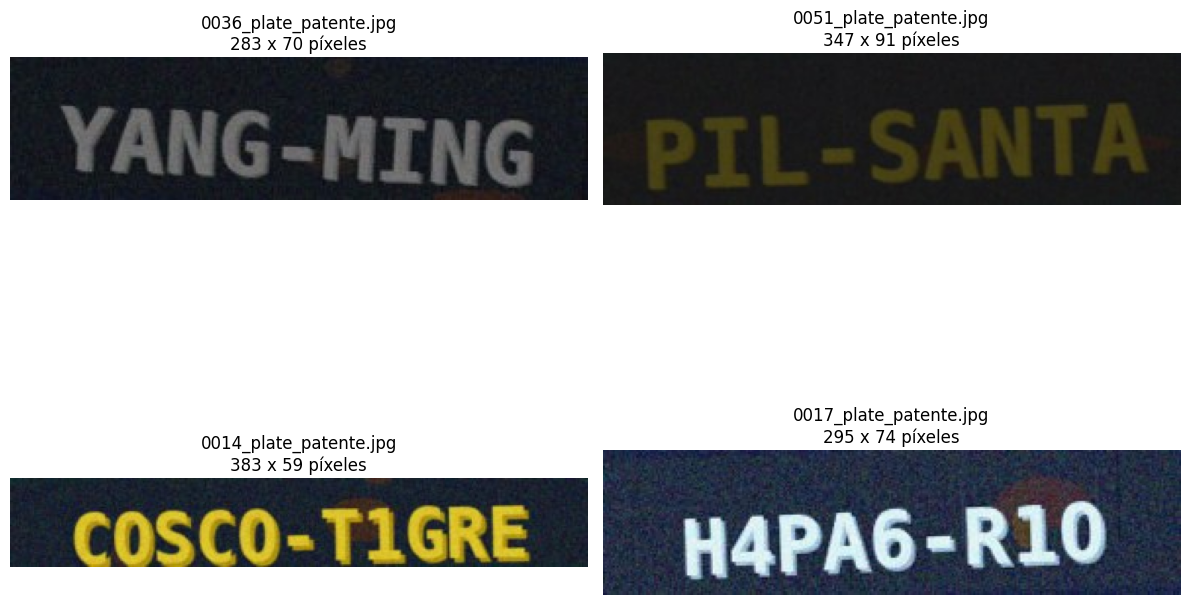

In [20]:
#@title E02. Muestra del grupo plates

mostrar_muestra(group_images["plates"], cantidad_mostrar=4)

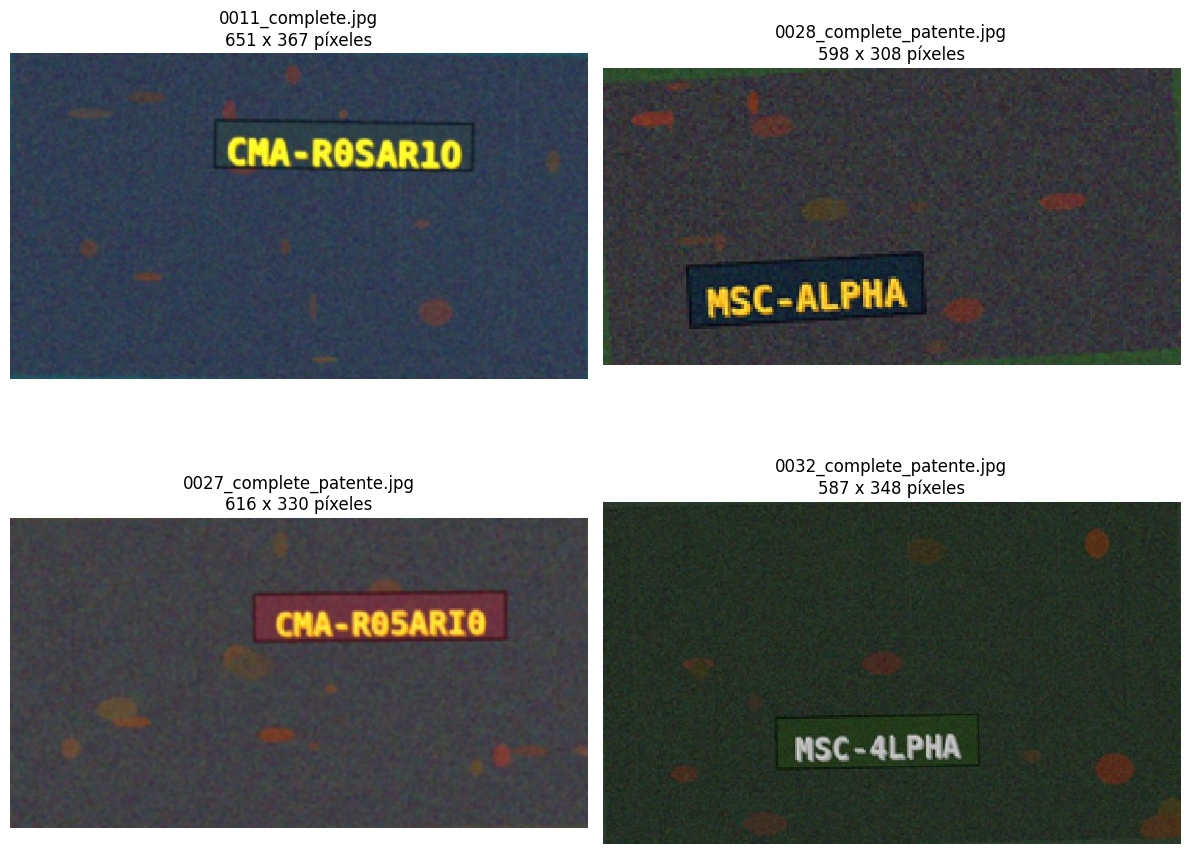

In [21]:
#@title E02. Muestra del grupo completes

mostrar_muestra(group_images["completes"], cantidad_mostrar=4)

In [22]:
#@title E02. Commit y push Día 2
tracear_ejercicio(
    repo,
    log,
    ChangelogEntry(
        day=2,
        changes=(
            "Listado y cálculo de tamaño en KB de todas las imágenes disponibles.",
            "Clasificación de imágenes en dos grupos: `plates` y `completes` según su nombre.",
            "Generación y guardado de `port_log/data/interim/group_images.json`.",
            "Cálculo de estadísticas promedio para cada grupo.",
            "Implementación de la función `mostrar_muestra` para visualización de imágenes.",
        ),
    ),
    commit_files=[
        "port_log/data/interim/group_images.json",
        "CHANGELOG.md",
    ],
    commit_message="Día 2: análisis inicial de imágenes, clasificación en plates/completes, creación de group_images.json y actualización de CHANGELOG",
    commit_username="Sofigam00s",
    commit_useremail="sofiykeity@gmail.com",
)

CHANGELOG: '### Ejercicio 02 — Día 2' ya estaba registrado.
Ejercicio ya traceado en changelog
On branch Sprint_2
Your branch is up to date with 'origin/Sprint_2'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   port_log/data/interim/group_images.json

no changes added to commit (use "git add" and/or "git commit -a")



# Ejercicio 03

> Puntos: 2

Preprocesamiento de imágenes. En cada sub-punto llamar a `mostrar_muestra` para visualizar los resultados.

- **A. Escala de grises**: convertir todas las imágenes originales y guardar en:
  - `port_log/data/interim/imgs/03_01_gray/plates`
  - `port_log/data/interim/imgs/03_01_gray/completes`

- **B. Ecualización de histograma**: aplicar sobre las imágenes en escala de grises para mejorar el contraste (útil para imágenes nocturnas o subexpuestas). Guardar en:
  - `port_log/data/interim/imgs/03_02_equalized/plates`
  - `port_log/data/interim/imgs/03_02_equalized/completes`

- **C. Suavizado**: aplicar blur gaussiano sobre las imágenes ecualizadas. Guardar en:
  - `port_log/data/interim/imgs/03_03_blur/plates`
  - `port_log/data/interim/imgs/03_03_blur/completes`

- **D. Detección de bordes (Canny)**: aplicar sobre las imágenes suavizadas. Guardar en:
  - `port_log/data/interim/imgs/03_04_canny/plates`
  - `port_log/data/interim/imgs/03_04_canny/completes`




/content/Port_Log-Grupo_16/port_log/data/interim/imgs/03_01_gray/plates: 60 imágenes guardadas.


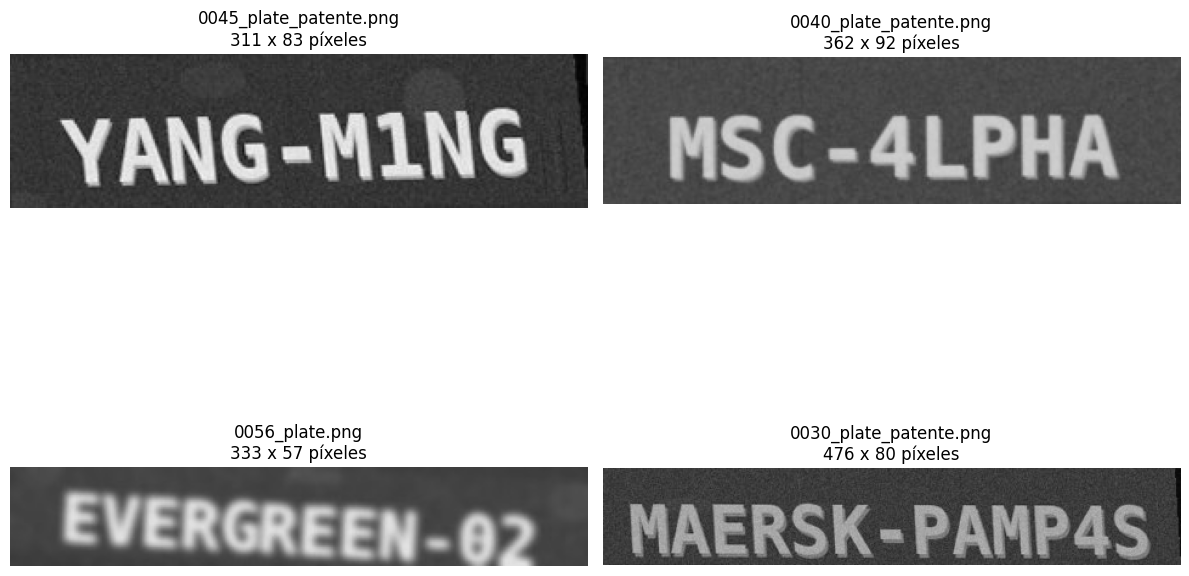

/content/Port_Log-Grupo_16/port_log/data/interim/imgs/03_01_gray/completes: 40 imágenes guardadas.


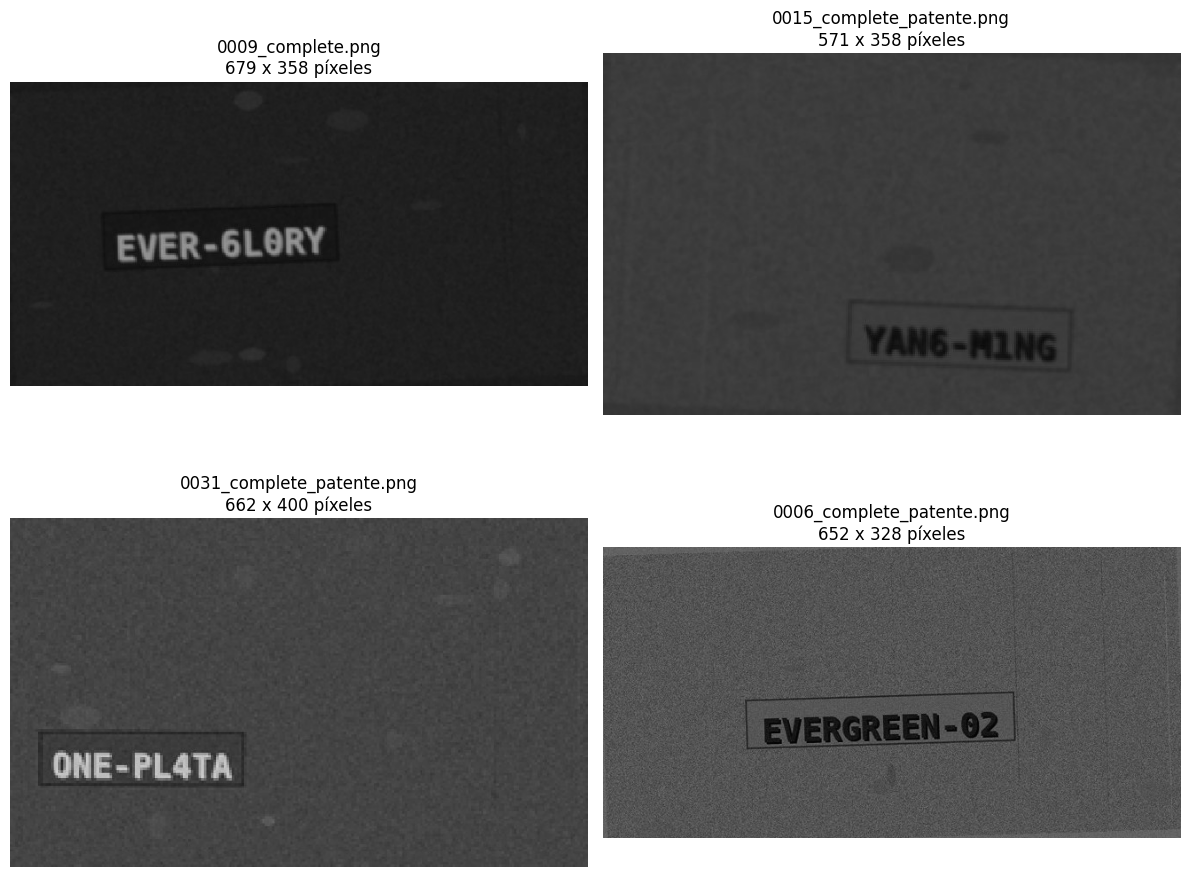

In [23]:
#@title E03. A. Escala de grises — Ivan Agustin Sandiyu

def procesar_etapa(
    grupos: dict[str, list[dict[str, Any]]],
    carpeta_salida: Path,
    transformacion: Callable[[np.ndarray], np.ndarray],
) -> dict[str, list[dict[str, Any]]]:
    """Procesa ambos grupos sin modificar los originales ni sus metadatos.

    Guarda PNG sin pérdida para conservar intensidades y bordes. Devuelve
    metadatos nuevos que permiten encadenar etapas y mostrar sus muestras.
    """
    resultados: dict[str, list[dict[str, Any]]] = {}
    for grupo in ("plates", "completes"):
        destino = carpeta_salida / grupo
        destino.mkdir(parents=True, exist_ok=True)
        resultados[grupo] = []

        for datos in grupos[grupo]:
            origen = Path(datos["path"])
            imagen = cv.imread(str(origen), cv.IMREAD_UNCHANGED)
            if imagen is None:
                raise ValueError(f"No se pudo abrir la imagen {origen}")

            procesada = transformacion(imagen)
            ruta_salida = destino / f"{origen.stem}.png"
            if not cv.imwrite(str(ruta_salida), procesada):
                raise OSError(f"No se pudo guardar la imagen {ruta_salida}")

            alto, ancho = procesada.shape[:2]
            resultados[grupo].append({
                **datos,
                "filename": ruta_salida.name,
                "width": int(ancho),
                "height": int(alto),
                "area": int(ancho * alto),
                "path": str(ruta_salida),
            })

        print(f"{destino}: {len(resultados[grupo])} imágenes guardadas.")
        mostrar_muestra(resultados[grupo])

    return resultados


def convertir_a_grises(imagen: np.ndarray) -> np.ndarray:
    """Convierte imágenes BGR/BGRA a grises; conserva las ya monocromas."""
    if imagen.ndim == 2:
        return imagen.copy()
    conversion = (
        cv.COLOR_BGRA2GRAY if imagen.shape[2] == 4
        else cv.COLOR_BGR2GRAY
    )
    return cv.cvtColor(imagen, conversion)


DIR_PREPROCESAMIENTO = repo.path / "port_log/data/interim/imgs"
imagenes_gray = procesar_etapa(
    group_images,
    DIR_PREPROCESAMIENTO / "03_01_gray",
    convertir_a_grises,
)

/content/Port_Log-Grupo_16/port_log/data/interim/imgs/03_02_equalized/plates: 60 imágenes guardadas.


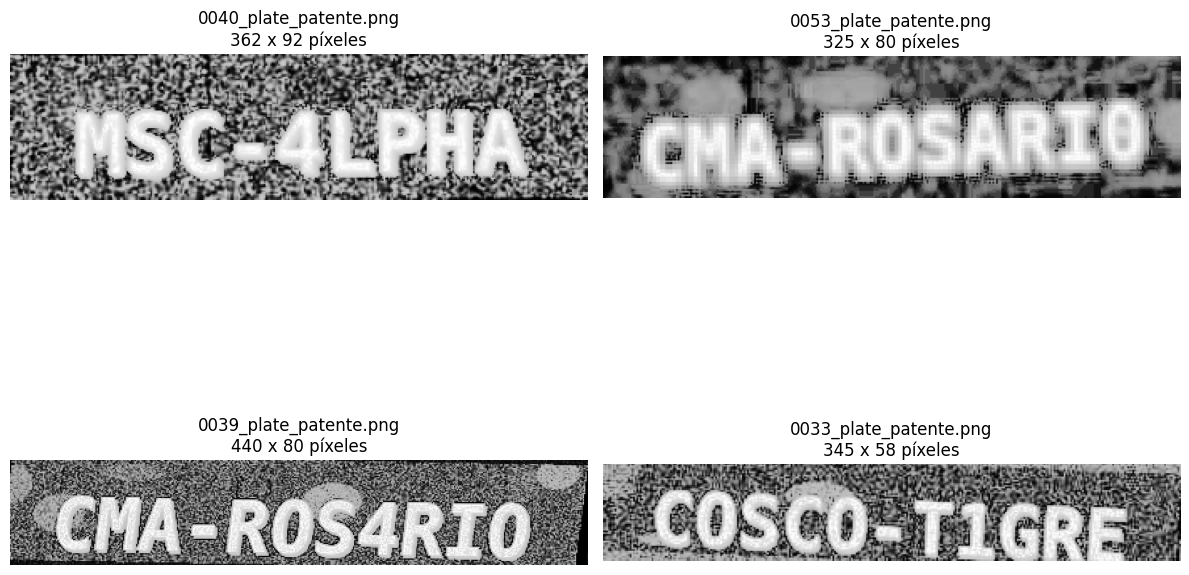

/content/Port_Log-Grupo_16/port_log/data/interim/imgs/03_02_equalized/completes: 40 imágenes guardadas.


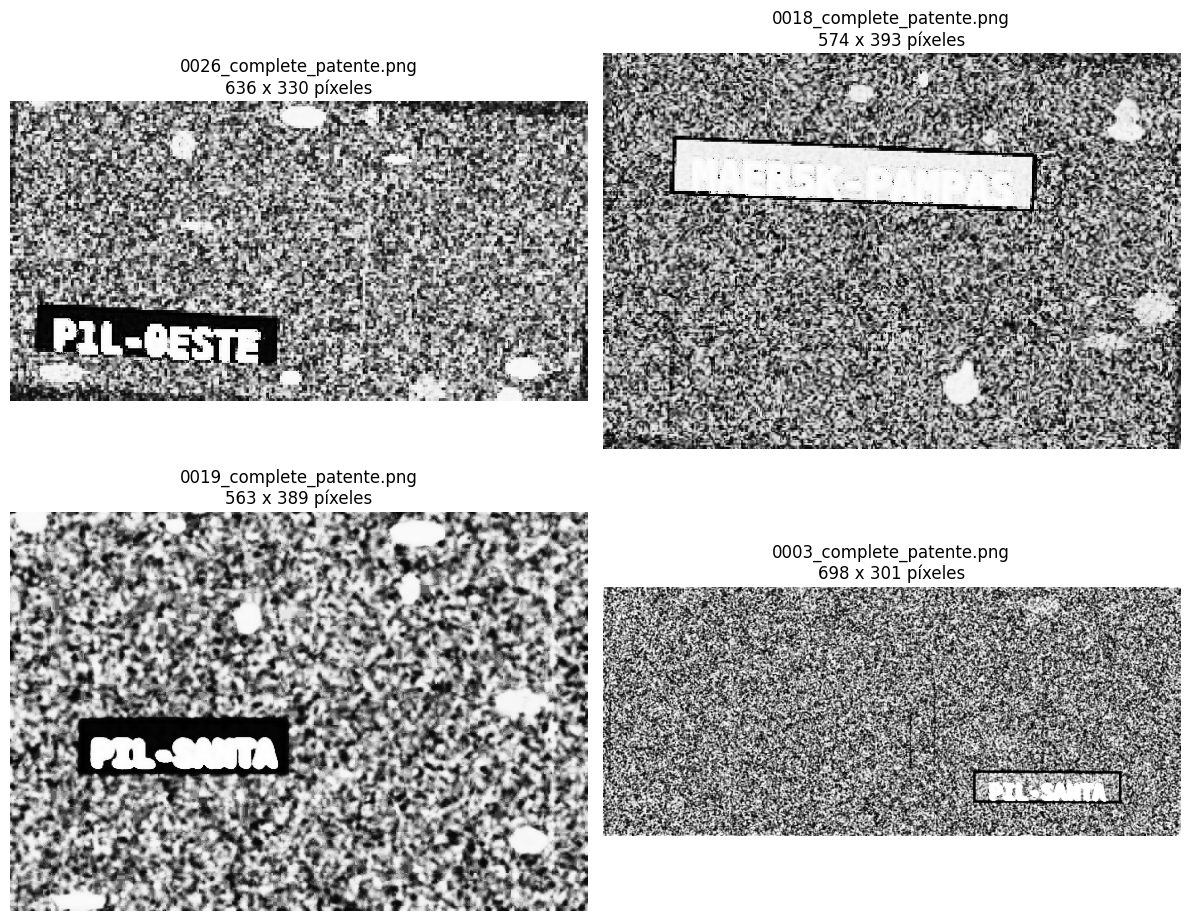

In [24]:
#@title E03. B. Ecualización del histograma

# Se ecualiza cada imagen gris para redistribuir sus intensidades.
imagenes_equalized = procesar_etapa(
    imagenes_gray,
    DIR_PREPROCESAMIENTO / "03_02_equalized",
    cv.equalizeHist,
)


/content/Port_Log-Grupo_16/port_log/data/interim/imgs/03_03_blur/plates: 60 imágenes guardadas.


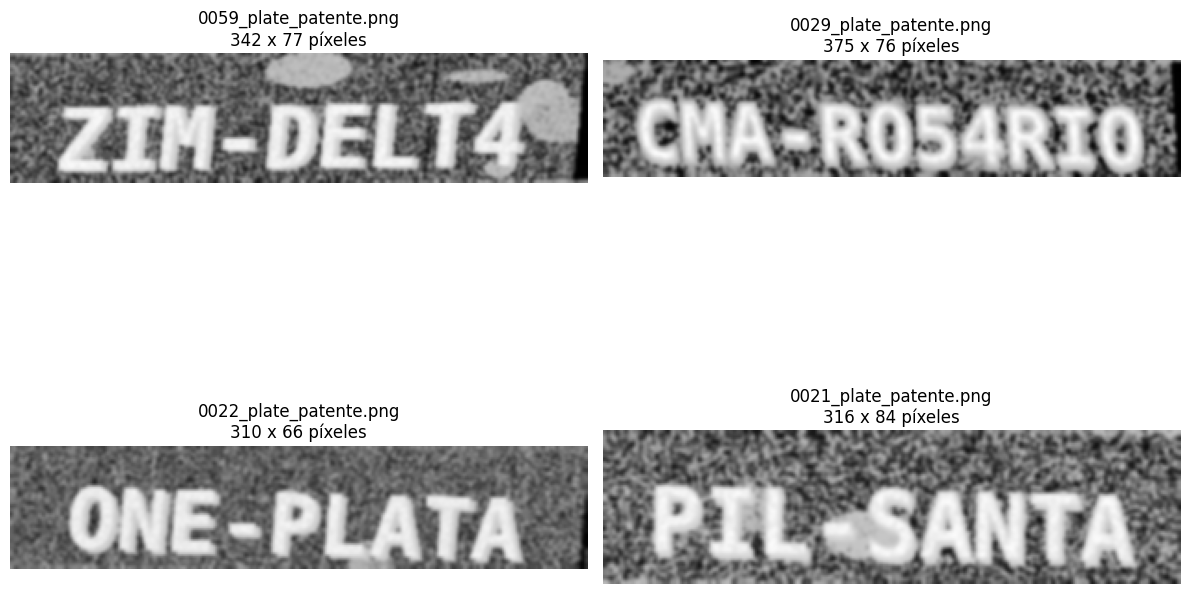

/content/Port_Log-Grupo_16/port_log/data/interim/imgs/03_03_blur/completes: 40 imágenes guardadas.


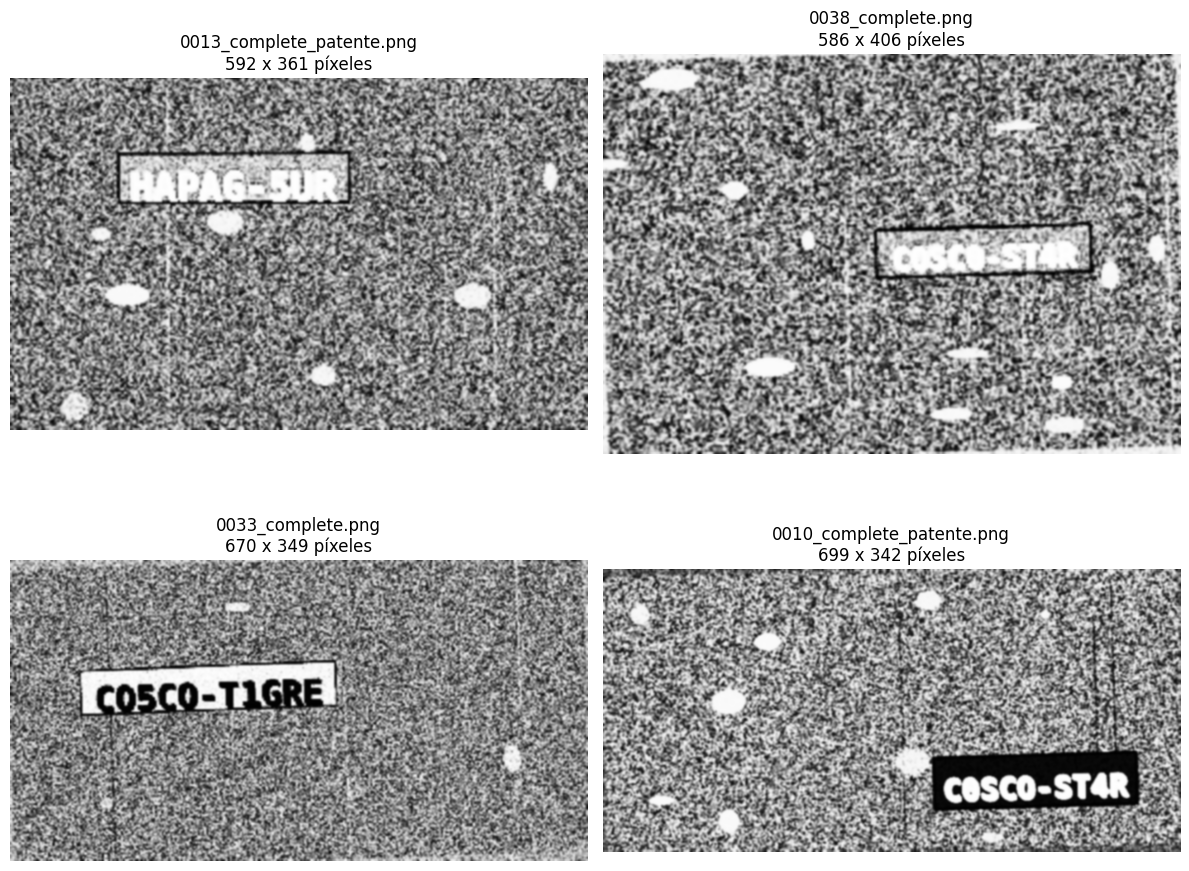

In [25]:
#@title E03. C. Suavizado gaussiano

def aplicar_blur(imagen: np.ndarray) -> np.ndarray:
    """Reduce ruido con una ventana 5 x 5 y sigma calculado por OpenCV."""
    return cv.GaussianBlur(imagen, (5, 5), sigmaX=0)


imagenes_blur = procesar_etapa(
    imagenes_equalized,
    DIR_PREPROCESAMIENTO / "03_03_blur",
    aplicar_blur,
)


/content/Port_Log-Grupo_16/port_log/data/interim/imgs/03_04_canny/plates: 60 imágenes guardadas.


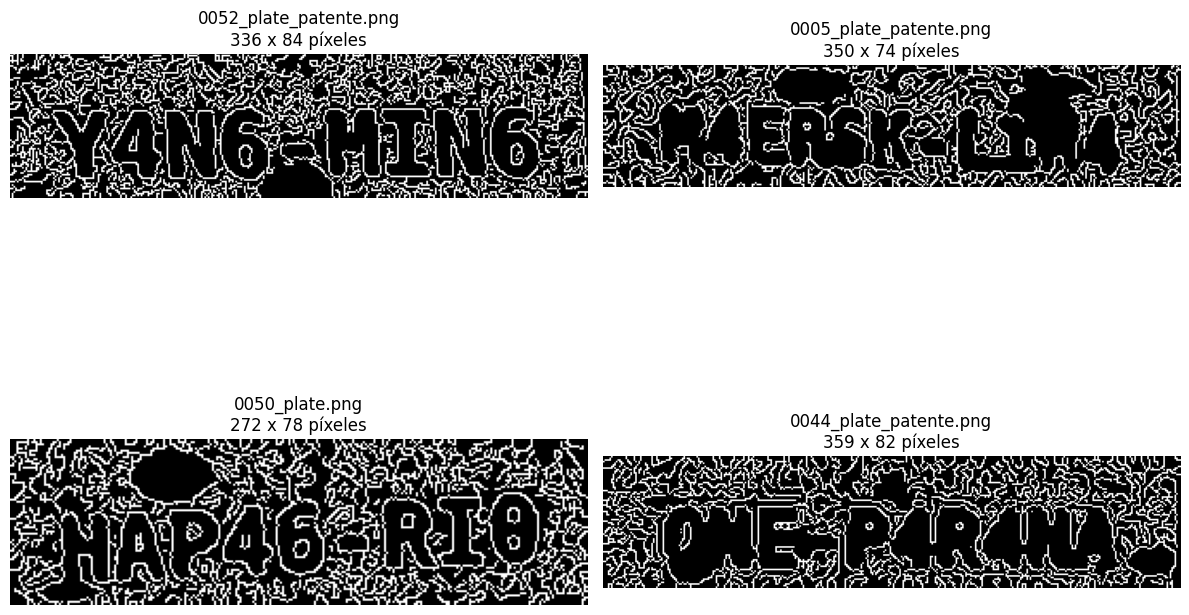

/content/Port_Log-Grupo_16/port_log/data/interim/imgs/03_04_canny/completes: 40 imágenes guardadas.


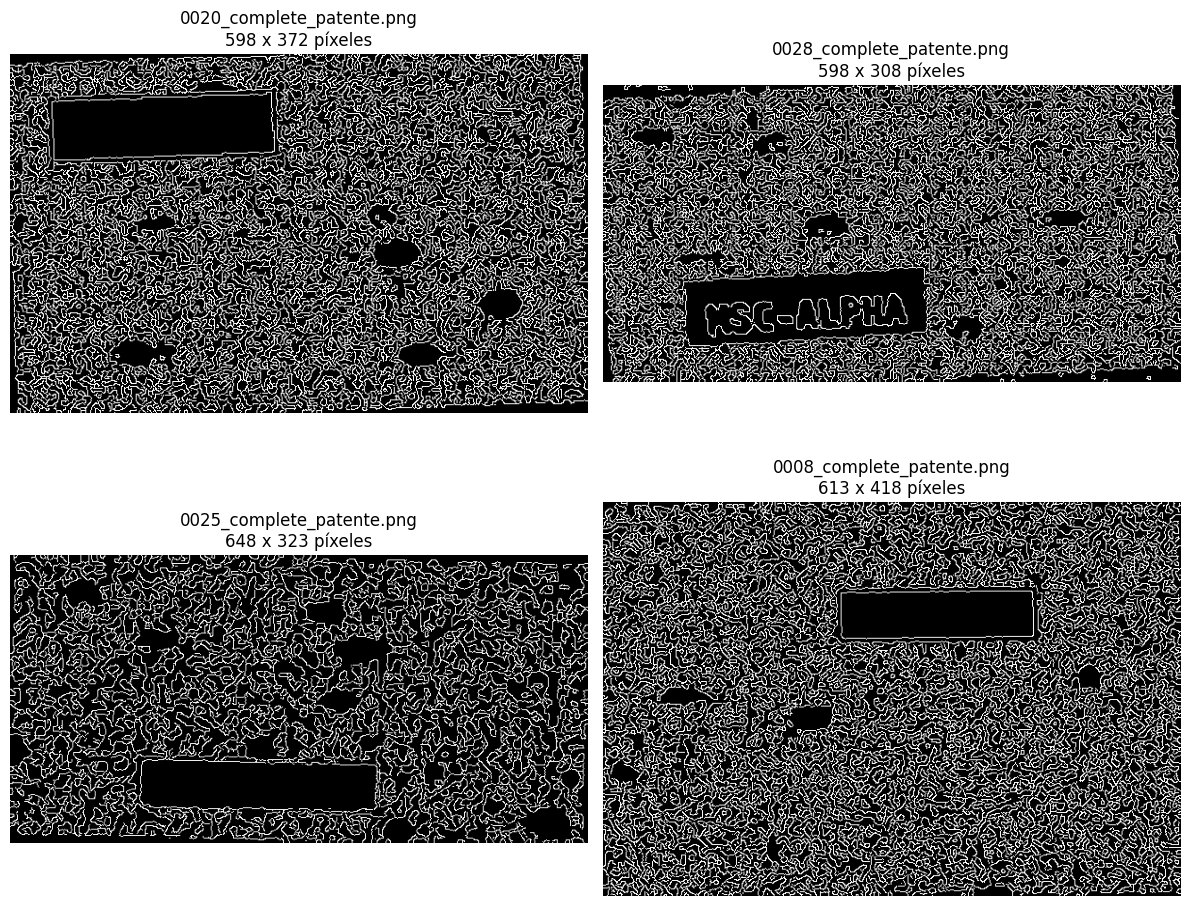

Preprocesamiento completo: originales → grises → ecualizadas → blur → Canny.
Los originales y group_images se conservan para los próximos ejercicios.


In [26]:
#@title E03. D. Detección de bordes con Canny

def detectar_bordes(imagen: np.ndarray) -> np.ndarray:
    """Detecta bordes sobre la imagen suavizada, con umbrales 100 y 200."""
    # Los bordes fuertes superan 200; los débiles entre 100 y 200 se
    # conservan cuando están conectados a bordes fuertes (histéresis).
    return cv.Canny(imagen, threshold1=100, threshold2=200)


imagenes_canny = procesar_etapa(
    imagenes_blur,
    DIR_PREPROCESAMIENTO / "03_04_canny",
    detectar_bordes,
)

print("Preprocesamiento completo: originales → grises → ecualizadas → blur → Canny.")
print("Los originales y group_images se conservan para los próximos ejercicios.")


In [27]:
#@title E03. Commit y push Día 3

tracear_ejercicio(
    repo,
    log,
    ChangelogEntry(
        day=3,
        changes=(
            "Conversión de las 100 imágenes originales a escala de grises y ecualización de histograma sobre esas salidas.",
            "Suavizado gaussiano (5 x 5, sigma automático) sobre las imágenes ecualizadas y detección de bordes Canny (100, 200) sobre las suavizadas.",
            "Guardado de 400 imágenes PNG sin pérdida en las cuatro carpetas solicitadas, separadas en plates (60) y completes (40) por etapa.",
            "Visualización de ambos grupos con mostrar_muestra en cada etapa; compatibilidad con imágenes monocromas y muestras de una o dos imágenes.",
            "Ejecución y verificación del ejercicio 3: dimensiones, resultados de las cuatro operaciones, repetibilidad y conservación de los originales y metadatos."
        ),
    ),
    commit_files=[
        "CHANGELOG.md",
        "port_log/data/interim/imgs/",
    ],
    commit_message="Día 5: Ejercicio 5. Analisis descriptivo de los resultados del nuevo dataset con vinculacion a las imagenes",
    commit_username="Ivan Agustin Sandiyu",
    commit_useremail="agustinkey21@gmail.com",
)


CHANGELOG: '### Ejercicio 03 — Día 3' ya estaba registrado.
Ejercicio ya traceado en changelog


# Ejercicio 04

> Puntos: 2

**Extracción de matrículas y matching con el dataset.**

Usar la función `extraer_matricula` (definida abajo) para obtener la matrícula de cada imagen. Almacenar el resultado en la key `matricula_imagen` del diccionario `group_images`.

Cruzar las matrículas extraídas con el dataset `port_log/data/interim/port_movements.csv`. Para el match se comparan caracteres alfanuméricos (ignorar guiones y espacios) de izquierda a derecha. Se considera coincidencia con **75% o más** de caracteres correctos en posición.

En caso de match, agregar al DataFrame (port_log/data/interim/port_movements.csv):
- `imagen`: path a la imagen.
- `matricula_imagen`: texto extraído por OCR.
- `ratio`: porcentaje de coincidencia.
- `grupo_imagen`: `"plates"` o `"completes"` según el grupo de origen.

Guardar el resultado en `port_log/data/processed/port_movements_image.csv`.

Ejemplos de matching (ignorando guiones):
| Matrícula Original | Detectada OCR | Alfanum. Original | Alfanum. Detectada | Match |
| --- | --- | --- | --- | --- |
| MSC-GENOVA | MSC-GEN0VA | MSCGENOVA | MSCGEN0VA | OK (88%) |
| MAERSK-LIMA | MAERSK-L1M | MAERSKLIMA | MAERSKL1M | ERROR (70%) |

`IMPORTANTE: Esta es una aproximación base.` Se aceptan mejoras como cierre morfológico, filtrado de contornos por aspecto o ROI.

`No se otorgan puntos extras por exploración más compleja, pero sí se considera para la nota de concepto final.`

In [28]:
#@title E04. Instalación de easyocr
!pip install -q easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 18.6 MB/s eta 0:00:00


In [29]:
#@title E04. Función extraer_matricula

import easyocr

reader = easyocr.Reader(['en'])
def extraer_matricula(image_path: str) -> str:
  """Extrae la matrícula de un buque desde una imagen.

  Args:
      image_path (str): Ruta de la imagen.

  Returns:
      str: Texto detectado o cadena vacía si no hay detección.
  """
  detection: list = reader.readtext(image_path)
  if not detection:
    return ''
  return ''.join(
    d[1] for d in detection
    if isinstance(d, tuple) and len(d) == 3
    and isinstance(d[1], str)
  )

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [30]:
#@title E04. Extraer matrículas con OCR

# Rutas que ya deberían existir del Día 1 y Día 2
GROUP_IMAGES_PATH = repo.path / "port_log/data/interim/group_images.json"
IMGS_DIR = repo.path / "port_log/data/raw/imgs"

# Cargamos el diccionario plates / completes con metadatos de cada foto
# with GROUP_IMAGES_PATH.open(encoding="utf-8") as archivo_json:
#     group_images = json.load(archivo_json)
# group_images esta declarada arriba, se genera siempre.


def resolver_ruta_imagen(datos_imagen: dict) -> Path:
    """Devuelve una ruta usable a la imagen.

    El JSON a veces guarda paths absolutos de otra sesión de Colab.
    Si ese path no existe, buscamos el archivo por nombre en raw/imgs.
    """
    ruta = Path(datos_imagen["path"])
    if ruta.is_file():
        return ruta

    alternativa = IMGS_DIR / datos_imagen["filename"]
    if alternativa.is_file():
        print("alguna vez lo es?")
        return alternativa

    raise FileNotFoundError(
        f"No se encontró la imagen {datos_imagen['filename']}"
    )


# Contador solo para ir viendo el progreso en pantalla
total = sum(len(lista) for lista in group_images.values())
procesadas = 0

# Recorremos los dos grupos y cada imagen
for grupo, lista_imagenes in group_images.items():
    for datos_imagen in lista_imagenes:
        ruta_imagen = resolver_ruta_imagen(datos_imagen)

        # Actualizamos el path por si había quedado uno viejo
        datos_imagen["path"] = str(ruta_imagen)

        # Acá entra EasyOCR: lee el texto de la foto
        datos_imagen["matricula_imagen"] = extraer_matricula(str(ruta_imagen))

        procesadas += 1
        print(
            f"[{procesadas}/{total}] {grupo} | "
            f"{datos_imagen['filename']} -> "
            f"{datos_imagen['matricula_imagen']!r}"
        )

# Guardamos el JSON ya con matricula_imagen completa
GROUP_IMAGES_PATH.parent.mkdir(parents=True, exist_ok=True)
with GROUP_IMAGES_PATH.open("w", encoding="utf-8") as archivo_json:
    json.dump(group_images, archivo_json, indent=2, ensure_ascii=False)

print(f"OCR guardado en {GROUP_IMAGES_PATH}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[1/100] plates | 0001_plate_patente.jpg -> 'PIL-SanTA'


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[2/100] plates | 0002_plate.jpg -> 'MSC -GENOVA'


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[98/100] completes | 0038_complete.jpg -> 'coscO-St4r'


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[99/100] completes | 0039_complete_patente.jpg -> 'Hapag-RIO'
[100/100] completes | 0040_complete.jpg -> 'Fa Fng'
OCR guardado en /content/Port_Log-Grupo_16/port_log/data/interim/group_images.json


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [31]:
#@title E04. Matching con port_movements y export CSV
MOVIMIENTOS_PATH = repo.path / "port_log/data/interim/port_movements.csv"
PROCESSED_PATH = repo.path / "port_log/data/processed/port_movements_image.csv"

# El enunciado pide 75% o más de caracteres correctos en posición
UMBRAL_MATCH = 75.0

# Dataset limpio del Sprint 1 (una fila = un movimiento / infracción)
movimientos = pd.read_csv(MOVIMIENTOS_PATH)

def solo_alfanum(texto: str) -> str:
    """Saca guiones, espacios y deja solo letras/números en mayúsculas."""
    return "".join(
        caracter for caracter in str(texto).upper() if caracter.isalnum()
    )

def calcular_ratio(matricula_original: str, matricula_detectada: str) -> float:
    """Compara de izquierda a derecha, posición por posición.

    Ejemplo del enunciado:
    MSCGENOVA vs MSCGEN0VA -> 8/9 = 88.89%
    """
    original = solo_alfanum(matricula_original)
    detectada = solo_alfanum(matricula_detectada)

    if not original:
        return 0.0

    aciertos = sum(
        1
        for i, caracter in enumerate(original)
        if i < len(detectada) and caracter == detectada[i]
    )
    return (aciertos / len(original)) * 100


# Aplanamos group_images a una lista simple de candidatos OCR
imagenes_ocr = []
for grupo, lista_imagenes in group_images.items():
    for datos_imagen in lista_imagenes:
        imagenes_ocr.append(
            {
                "grupo_imagen": grupo,
                "imagen": datos_imagen["path"],
                "matricula_imagen": datos_imagen.get("matricula_imagen", ""),
            }
        )

# Para cada movimiento del CSV, buscamos la mejor imagen que pase el umbral
mejores_matches = []
for _, fila in movimientos.iterrows():
    mejor = None

    for imagen_ocr in imagenes_ocr:
        ratio = calcular_ratio(fila["matricula"], imagen_ocr["matricula_imagen"])

        # Por debajo de 75% no cuenta como match
        if ratio < UMBRAL_MATCH:
            continue

        candidato = {
            "imagen": imagen_ocr["imagen"],
            "matricula_imagen": imagen_ocr["matricula_imagen"],
            "ratio": round(ratio, 2),
            "grupo_imagen": imagen_ocr["grupo_imagen"],
        }

        # Primera imagen válida
        if mejor is None:
            mejor = candidato
            continue

        # Preferimos mayor ratio
        if candidato["ratio"] > mejor["ratio"]:
            mejor = candidato
            continue

        # Si empatan en ratio, preferimos plates (recorte de matrícula)
        if (
            candidato["ratio"] == mejor["ratio"]
            and candidato["grupo_imagen"] == "plates"
            and mejor["grupo_imagen"] != "plates"
        ):
            mejor = candidato

    mejores_matches.append(mejor)

# Agregamos las 4 columnas que pide el enunciado
movimientos["imagen"] = [
    m["imagen"] if m else "" for m in mejores_matches
]
movimientos["matricula_imagen"] = [
    m["matricula_imagen"] if m else "" for m in mejores_matches
]
movimientos["ratio"] = [
    m["ratio"] if m else None for m in mejores_matches
]
movimientos["grupo_imagen"] = [
    m["grupo_imagen"] if m else "" for m in mejores_matches
]

# Exportamos el dataset final del Día 4
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
movimientos.to_csv(PROCESSED_PATH, index=False)

con_match = movimientos["imagen"].astype(str).str.len() > 0
print(f"Movimientos totales: {len(movimientos)}")
print(f"Con imagen asociada: {int(con_match.sum())}")
print(f"Sin imagen asociada: {int((~con_match).sum())}")
print(f"CSV guardado en: {PROCESSED_PATH}")

# Vista rápida de algunos matches
movimientos.loc[
    con_match, ["matricula", "matricula_imagen", "ratio", "grupo_imagen"]
].head(10)

Movimientos totales: 447
Con imagen asociada: 431
Sin imagen asociada: 16
CSV guardado en: /content/Port_Log-Grupo_16/port_log/data/processed/port_movements_image.csv


,matricula,matricula_imagen,ratio,grupo_imagen
0,ONE-PLATA,ONE-PLATA,100.0,plates
1,ONE-PARANA,ONE - PARANA,100.0,plates
2,ZIM-DELTA,ZIM-DELTA,100.0,completes
3,MAERSK-PAMPAS,MAERSK -PAMPAS,100.0,plates
4,COSCO-TIGRE,CoscO-TIGRE,100.0,plates
5,PIL-SANTA,PIL-SanTA,100.0,plates
6,YANG-MING,YANG-MING,100.0,plates
7,YANG-ESTE,YANG-ESTE,100.0,plates
9,PIL-SANTA,PIL-SanTA,100.0,plates
10,MAERSK-LIMA,MAERSK-LIMA,100.0,plates


In [32]:
#@title E04. Commit y push Día 4
tracear_ejercicio(
    repo,
    log,
    ChangelogEntry(
        day=4,
        changes=(
            "Extracción de matrículas con EasyOCR sobre plates y completes.",
            "Matching alfanumérico ≥ 75% contra port_movements.csv.",
            "Export de port_log/data/processed/port_movements_image.csv.",
            "Actualización de group_images.json con matricula_imagen.",
        ),
    ),
    commit_files=[
        "port_log/data/interim/group_images.json",
        "port_log/data/processed/port_movements_image.csv",
        "CHANGELOG.md",
    ],
    commit_message="Día 4: OCR de matrículas, matching ≥75% y port_movements_image.csv",
    commit_username="HectorOviedoM",
    commit_useremail="oviedohectorm@gmail.com",
)

CHANGELOG: '### Ejercicio 04 — Día 4' ya estaba registrado.
Ejercicio ya traceado en changelog
On branch Sprint_2
Your branch is up to date with 'origin/Sprint_2'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   port_log/data/interim/group_images.json
	modified:   port_log/data/processed/port_movements_image.csv

no changes added to commit (use "git add" and/or "git commit -a")



# Ejercicio 05

> Puntos: 2

Métricas del dataset final en `port_log/data/processed/port_movements_image.csv`:

- A. Infracciones sin imagen asociada:
```
La cantidad de infracciones sin imagen es: XX
```

- B. Infracciones con imagen asociada:
```
La cantidad de infracciones con imagen es: XX
```

- C. Imágenes sin match en el dataset:
```
La cantidad de imágenes sin match son: XX
```


- D. Ratio promedio de coincidencia de los matches encontrados:
```
El ratio promedio de coincidencia es: XX.XX%
```


- E. ¿Qué grupo tuvo mayor tasa de match exitoso, `plates` o `completes`?
```
El grupo con mayor tasa de match es 'XXXXX' con XX.XX%
```


- F. Infracciones en estado `PENDIENTE` sin imagen asociada:
```
Infracciones PENDIENTES sin evidencia visual: XX
```




In [33]:
#@title E05. A. Infracciones sin imagen asociada
mascara_sin_imagen = movimientos["imagen"].ne("")
infracciones_sin_imagen = movimientos.loc[
   mascara_sin_imagen, "imagen"
].shape[0]
print(f"La cantidad de infracciones sin imagen es: {infracciones_sin_imagen}")

La cantidad de infracciones sin imagen es: 431


In [34]:
#@title E05. B. Infracciones con imagen asociada
infracciones_con_imagen = movimientos.loc[
   ~mascara_sin_imagen, "imagen"
].shape[0]
print(f"La cantidad de infracciones con imagen es: {infracciones_con_imagen}")

La cantidad de infracciones con imagen es: 16


In [35]:
#@title E05. C. Imágenes sin match en el dataset
mascara_sin_match = movimientos["ratio"].isna()
infracciones_sin_match = movimientos.loc[
   mascara_sin_match, "imagen"
]
print(f"La cantidad de infracciones sin match es: {infracciones_sin_match.shape[0]}")

La cantidad de infracciones sin match es: 16


In [36]:
#@title E05. D. Ratio promedio de coincidencia en matches
movientos_not_na = movimientos[~mascara_sin_match]
print(f"El ratio promedio de coincidencia es: {movientos_not_na["ratio"].mean()}")

El ratio promedio de coincidencia es: 100.0


In [37]:
#@title E05. E. Grupos con mayor tasa de exito

agrupados = movientos_not_na.groupby("grupo_imagen")["ratio"].mean()
display(agrupados)
print(f"El grupo con mayor tasa de match es {agrupados.idxmax()} con {agrupados.max()}%")

,ratio
grupo_imagen,
completes,100.0
plates,100.0


El grupo con mayor tasa de match es completes con 100.0%


In [38]:
#@title E05. F. PENDIENTES sin evidencia visual
pendientes_sin_imagen = movimientos.loc[
    movimientos["estado_despacho"].eq("PENDIENTE") & ~con_match
]
print(f"Las siguientes {pendientes_sin_imagen.shape[0]} infracciones estan pendientes de despacho y no tienen evidencia visual")
display(pendientes_sin_imagen)

Las siguientes 2 infracciones estan pendientes de despacho y no tienen evidencia visual


,movimiento_id,buque_id,matricula,radar_id,muelle,tipo_carga,origen,fecha_ingreso,hora_ingreso,fecha_egreso,...,estado_despacho,hora_ingreso_imputada,hora_egreso_imputada,duracion_horas,exceso_velocidad_real,exceso_velocidad,imagen,matricula_imagen,ratio,grupo_imagen
186,MOV-00609,B-016,ZIM-NORTE,R-05,MUELLE-A,CONTENEDORES,ROTTERDAM,2020-08-30,13:31,2020-08-30,...,PENDIENTE,False,False,NaN,3.0,2.5,,,NaN,
435,MOV-01469,B-029,ZIM-NORTE,R-04,MUELLE-B,TRIGO,VALPARAISO,2020-06-11,17:32,2020-06-14,...,PENDIENTE,False,False,68.316667,1.7,1.1,,,NaN,


In [39]:
log.print_head()

# Changelog

## Sprint 2

### Ejercicio 04 — Día 4
- Extracción de matrículas con EasyOCR sobre plates y completes.
- Matching alfanumérico ≥ 75% contra port_movements.csv.
- Export de port_log/data/processed/port_movements_image.csv.
- Actualización de group_images.json con matricula_imagen.



In [40]:
#@title E05. Commit y push Día 5

tracear_ejercicio(
    repo,
    log,
    ChangelogEntry(
        day=5,
        changes=(
            "Correción de guardado de paths absolutas",
            "Analisis explorativo: infracciones con y sin imagen",
            "Analisis explorativo: ratios promedios",
            "Analisis explorativo: tasa de exito por grupo",
            "Analisis explorativo: pendientes con evidencia visual",
        ),
    ),
    commit_files=[
        "CHANGELOG.md",
        "port_log/data/interim/group_images.json",
        "port_log/data/interim/imgs/",
        "port_log/data/processed/",
        "port_log/data/raw/imgs/",
    ],
    commit_message="Día 5: Ejercicio 5. Analisis descriptivo de los resultados del nuevo dataset con vinculacion a las imagenes",
    commit_username="alexander5109",
    commit_useremail="xanderseling@gmail.com",
)


CHANGELOG: '### Ejercicio 05 — Día 5' agregado.

Git: identidad cambiada a alexander5109 <xanderseling@gmail.com>.
GIT: ADDING ['CHANGELOG.md', 'port_log/data/interim/group_images.json', 'port_log/data/interim/imgs/', 'port_log/data/processed/', 'port_log/data/raw/imgs/']
GIT: commit creado: Día 5: Ejercicio 5. Analisis descriptivo de los resultados del nuevo dataset con vinculacion a las imagenes
Git: rama 'Sprint_2' subida a origin.


# Ejercicio 06

> Puntos: 1

Redactar una conclusión sobre la relación entre los datos tabulares y las imágenes capturadas. Incluir:

- ¿Qué porcentaje de las infracciones pudo validarse visualmente?
- ¿Qué grupo de imágenes (`plates` o `completes`) resultó más útil para el OCR y por qué?
- ¿Qué condiciones de captura (nocturna, lejana, borrosa) afectaron más al matching?
- ¿Qué mejoras propondrías en el sistema de captura o en el algoritmo de matching?

In [42]:
!pwd
!git status


On branch Sprint_2
nothing to commit, working tree clean
/content/Port_Log-Grupo_16
